# The Butcher-Connes-Kreimer (BCK) Hopf Algebra

The BCK Hopf algebra, introduced by Connes and Kreimer (1998) in the context of renormalization
in quantum field theory, is a commutative, non-cocommutative, connected, graded Hopf algebra
of rooted trees. It was independently discovered by Butcher (1972) in the study of Runge-Kutta
methods for ordinary differential equations.

The algebra is the free commutative algebra generated by rooted trees, i.e., the polynomial
algebra $\mathbb{R}[\mathcal{T}]$ where $\mathcal{T}$ denotes the set of rooted trees.
The product is given by the disjoint union (forest concatenation), and the unit is the empty
tree $\emptyset$. The coalgebra structure is defined by admissible cuts on trees.

**Key references:**
- A. Connes and D. Kreimer, *Hopf algebras, renormalization and noncommutative geometry*, Comm. Math. Phys. **199** (1998), 203-242.
- C. Brouder, *Runge-Kutta methods and renormalization*, Eur. Phys. J. C **12** (2000), 521-534, [arXiv:hep-th/9904014](https://arxiv.org/abs/hep-th/9904014).
- H. Figueroa and J.M. Gracia-Bondia, *On the antipode of Kreimer's Hopf algebra*, [arXiv:hep-th/9912170](https://arxiv.org/abs/hep-th/9912170).

In [1]:
import kauri as kr
import kauri.bck as bck
from fractions import Fraction
from math import isclose

## 2. Trees in kauri

Rooted trees are the fundamental objects of the BCK Hopf algebra. In kauri, a `Tree` is
constructed from a nested list, where each inner list represents the subtrees attached
to the root. The empty tree (the unit of the Hopf algebra) is represented by `Tree(None)`.

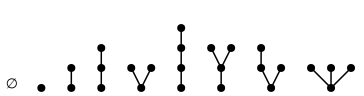

In [2]:
# The empty tree (unit of the Hopf algebra)
empty = kr.Tree(None)

# Order 1: the single-vertex tree (bullet)
bullet = kr.Tree([])

# Order 2: the chain of length 2
chain2 = kr.Tree([[]])

# Order 3: two non-isomorphic trees
chain3 = kr.Tree([[[]]])      # the chain of length 3
cherry = kr.Tree([[], []])    # the cherry (two branches from root)

# Order 4: four non-isomorphic trees
chain4 = kr.Tree([[[[]]]])         # chain of length 4
cherry_chain = kr.Tree([[[], []]])  # cherry attached to root via edge
fork = kr.Tree([[[]], []])          # chain2 and bullet from root
trident = kr.Tree([[], [], []])     # three branches from root

kr.display(empty, bullet, chain2, chain3, cherry, chain4, cherry_chain, fork, trident)

Number of trees up to order 5 (including empty tree): 18


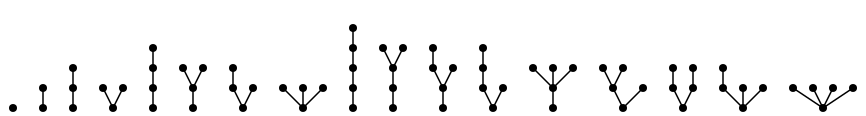

In [3]:
# All trees up to order 5, generated in lexicographic order
trees = list(kr.trees_up_to_order(5))
print(f"Number of trees up to order 5 (including empty tree): {len(trees)}")
kr.display(*[t for t in trees if t.nodes() > 0])

## 3. Coproduct

The BCK coproduct $\Delta_{BCK}: H \to H \otimes H$ is defined recursively via
admissible cuts. For a tree $t$ and subtrees $t_1, \ldots, t_k$
(i.e., $t = B_+(t_1 \cdots t_k)$ where $B_+$ is the grafting operator), the
coproduct satisfies:

$$
\Delta_{BCK}(t) = t \otimes \emptyset + (\text{id} \otimes B_+) \circ \Delta_{BCK}(t_1 \cdots t_k)
$$

Equivalently, in terms of admissible cuts:

$$
\Delta_{BCK}(t) = t \otimes \emptyset + \emptyset \otimes t + \sum_c P^c(t) \otimes R^c(t)
$$

where the sum runs over all admissible cuts $c$ of $t$, $P^c(t)$ is the pruned part
(the forest of branches removed by the cut), and $R^c(t)$ is the trunk (the remaining
connected subtree containing the root).

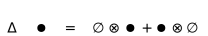

In [4]:
# Delta(bullet) = bullet (x) empty + empty (x) bullet
kr.display("Δ", bullet, "=", bck.coproduct(bullet))

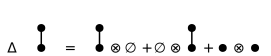

In [5]:
# Delta(chain2) = chain2 (x) empty + empty (x) chain2 + bullet (x) bullet
# The single admissible cut removes the root edge, yielding P = bullet, R = bullet.
kr.display("Δ", chain2, "=", bck.coproduct(chain2))

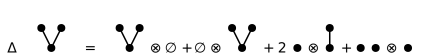

In [6]:
# Delta(cherry) = cherry (x) empty + empty (x) cherry
#               + bullet*bullet (x) bullet + 2 * bullet (x) chain2
# There are three admissible cuts:
#   - Cut both edges from root: P = bullet*bullet, R = bullet
#   - Cut the left edge: P = bullet, R = chain2
#   - Cut the right edge: P = bullet, R = chain2 (same result)
# The two single-edge cuts give the same result, hence the coefficient 2.
kr.display("Δ", cherry, "=", bck.coproduct(cherry))

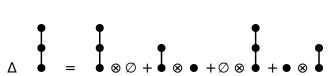

In [7]:
# Delta(chain3) = chain3 (x) empty + empty (x) chain3
#               + chain2 (x) bullet + bullet (x) chain2
# Two admissible cuts: cut the top edge or the bottom edge.
kr.display("Δ", chain3, "=", bck.coproduct(chain3))

Coproducts of order-4 trees:


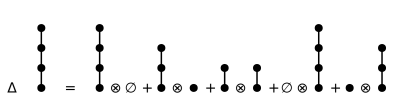

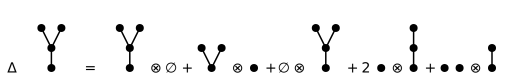

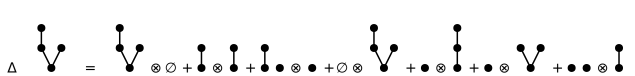

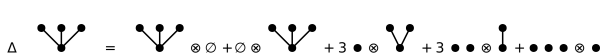

In [8]:
# Coproducts of all order-4 trees
print("Coproducts of order-4 trees:")
for t in kr.trees_of_order(4):
    kr.display("Δ", t, "=", bck.coproduct(t))
    print()

## 4. Antipode

The antipode $S: H \to H$ of the BCK Hopf algebra is defined recursively by:

$$
S(\emptyset) = \emptyset, \quad S(t) = -t - \sum_c S(P^c(t)) \cdot R^c(t)
$$

where the sum runs over all proper admissible cuts of $t$.

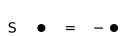

In [9]:
# S(bullet) = -bullet
kr.display("S", bullet, "=", bck.antipode(bullet))

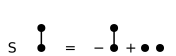

In [10]:
# S(chain2) = -chain2 + bullet^2
kr.display("S", chain2, "=", bck.antipode(chain2))

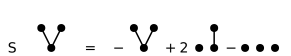

In [11]:
# S(cherry) = -cherry + 2*bullet*chain2 - bullet^3
kr.display("S", cherry, "=", bck.antipode(cherry))

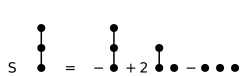

In [12]:
# S(chain3) = -chain3 + 2*bullet*chain2 - bullet^3
# Note: S(chain3) and S(cherry) share the same lower-order terms,
# differing only in the leading tree.
kr.display("S", chain3, "=", bck.antipode(chain3))

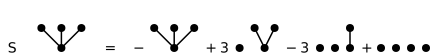

In [13]:
# S(trident) = -trident + 3*cherry*bullet - 3*chain2*bullet^2 + bullet^4
kr.display("S", trident, "=", bck.antipode(trident))

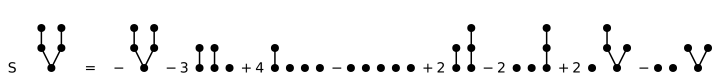

In [14]:
# Antipode of an order-5 tree: two_chain2s = Tree([[[]], [[]]])
# This is the tree with two chain2 subtrees attached to the root.
#
# Verified against Figueroa & Gracia-Bondia (2001), eq. 2.7,
# arXiv:hep-th/9912170.
two_chain2s = kr.Tree([[[]], [[]]])
kr.display("S", two_chain2s, "=", bck.antipode(two_chain2s))

## 5. Hopf Algebra Axioms

We now verify the defining axioms of the BCK Hopf algebra on all trees up to order 5.

### 5.1 Antipode property

The antipode $S$ satisfies:

$$
\mu \circ (S \otimes \text{id}) \circ \Delta = \eta \circ \varepsilon
$$

In other words, $S$ is the convolution inverse of the identity map:
$(S * \text{id})(t) = \varepsilon(t) \cdot \emptyset$ for all trees $t$.
For non-empty trees, this means $(S * \text{id})(t) = 0$.

In [15]:
# Compute (S * id)(t) for all trees up to order 5.
# This should equal counit(t) = 0 for all non-empty trees.
id_times_S = kr.ident * bck.antipode

antipode_property_holds = True
for t in kr.trees_up_to_order(5):
    if t.nodes() == 0:
        continue
    val = id_times_S(t)
    if val != 0:
        antipode_property_holds = False
        print(f"FAILED for {repr(t)}: got {val}")

print(f"Antipode property mu(S x id)(Delta) = eta*eps holds for all trees up to order 5: {antipode_property_holds}")

Antipode property mu(S x id)(Delta) = eta*eps holds for all trees up to order 5: True


### 5.2 Antipode is an involution

Since the BCK Hopf algebra is commutative, the antipode is an involution:

$$
S^2 = \text{id}
$$

This means $S(S(t)) = t$ for all trees $t$.

In [16]:
involution_holds = True
for t in kr.trees_up_to_order(5):
    if t.nodes() == 0:
        continue
    s_t = bck.antipode(t)
    s2_t = bck.antipode(s_t)  # Applies S to the ForestSum term-by-term
    if s2_t != t.as_forest_sum():
        involution_holds = False
        print(f"FAILED for {repr(t)}")

print(f"S^2 = id holds for all trees up to order 5: {involution_holds}")

S^2 = id holds for all trees up to order 5: True


### 5.3 Counit property

The counit $\varepsilon: H \to \mathbb{R}$ satisfies:

$$
(\varepsilon \otimes \text{id}) \circ \Delta = \text{id}
$$

In the BCK algebra, $\varepsilon(\emptyset) = 1$ and $\varepsilon(t) = 0$ for all
non-empty trees.

In [17]:
counit_property_holds = True
for t in kr.trees_up_to_order(5):
    cp = bck.coproduct(t)
    # Compute (eps x id)(Delta(t)): for each term (c, left, right),
    # multiply c * eps(left) * right, where eps is multiplicative on forests.
    result = 0
    for c_coeff, left, right in cp:
        eps_left = 1
        for tree_in_left in left.tree_list:
            eps_left *= bck.counit(tree_in_left)
        result += c_coeff * eps_left * right.as_forest_sum()
    if result != t.as_forest_sum():
        counit_property_holds = False
        print(f"FAILED for {repr(t)}")

print(f"Counit property (eps x id)(Delta) = id holds for all trees up to order 5: {counit_property_holds}")

Counit property (eps x id)(Delta) = id holds for all trees up to order 5: True


## 6. Application: B-series and Runge-Kutta Methods

A **B-series** is a formal power series indexed by rooted trees:

$$
B(\phi, y_0, h) = y_0 + \sum_{t \in \mathcal{T}} \frac{h^{|t|}}{\sigma(t)} \phi(t) \, F(t)(y_0)
$$

where $\phi: \mathcal{T} \to \mathbb{R}$ is a character (a map satisfying
$\phi(t_1 \cdot t_2) = \phi(t_1) \phi(t_2)$), $\sigma(t)$ is the symmetry factor,
and $F(t)$ is the elementary differential.

The elementary weights of any Runge-Kutta method define a character of the BCK Hopf
algebra. This connection, discovered by Butcher, is the algebraic foundation of the
order theory of numerical integrators.

### 6.1 Composition of B-series

The **composition** of two B-series corresponds to the **BCK convolution product** of
their characters. If $\phi$ and $\psi$ are characters, then the character of the
composed method is:

$$
(\phi * \psi)(t) = \mu \circ (\phi \otimes \psi) \circ \Delta_{BCK}(t)
$$

In kauri, this is computed using the `*` operator on `Map` objects, or equivalently
via `bck.map_product(phi, psi)`.

In [18]:
# The elementary weights of the exact solution: phi_exact(t) = 1/t!
phi_exact = kr.exact_weights

# Convolution square: exact_weights ** 2
# This corresponds to composing the exact flow with itself,
# i.e., taking two steps of size h is equivalent to one step of size 2h.
# Therefore phi_exact**2(t) = 2^|t| / t! (the weights for step size 2h).
phi_exact_sq = phi_exact ** 2

print("Composition of exact flow with itself (convolution square):")
print(f"{'Tree':>20s}  {'phi^2(t)':>12s}  {'2^|t| / t!':>12s}  {'Match':>6s}")
for t in kr.trees_up_to_order(4):
    if t.nodes() == 0:
        continue
    val = phi_exact_sq(t)
    expected = 2**t.nodes() / t.factorial()
    match = isclose(val, expected, rel_tol=1e-12)
    val_str = str(Fraction(val).limit_denominator(10000))
    exp_str = str(Fraction(expected).limit_denominator(10000))
    print(f"{repr(t):>20s}  {val_str:>12s}  {exp_str:>12s}  {str(match):>6s}")

Composition of exact flow with itself (convolution square):
                Tree      phi^2(t)    2^|t| / t!   Match
                  []             2             2    True
                [[]]             2             2    True
              [[[]]]           4/3           4/3    True
            [[], []]           8/3           8/3    True
            [[[[]]]]           2/3           2/3    True
          [[[], []]]           4/3           4/3    True
          [[[]], []]             2             2    True
        [[], [], []]             4             4    True


### 6.2 Convolution inverse and adjoint methods

The **convolution inverse** of a character $\phi$ in the BCK Hopf algebra is given by
composing with the antipode:

$$
\phi^{*(-1)} = \phi \circ S_{BCK}
$$

This satisfies $(\phi * \phi^{*(-1)})(t) = \varepsilon(t)$ for all trees.

For the identity map, $\text{id}^{*(-1)} = \text{id} \circ S = S$, recovering the antipode.

In [19]:
# The convolution inverse of exact_weights
phi_inv = kr.exact_weights ** (-1)

# Verify: phi * phi^(-1) = counit
phi_check = kr.exact_weights * phi_inv

inverse_holds = True
for t in kr.trees_up_to_order(5):
    if t.nodes() == 0:
        continue
    val = phi_check(t)
    if not isclose(val, 0, abs_tol=1e-10):
        inverse_holds = False
        print(f"FAILED for {repr(t)}: got {val}")

print(f"phi * phi^(-1) = counit holds for all trees up to order 5: {inverse_holds}")

phi * phi^(-1) = counit holds for all trees up to order 5: True


In [20]:
# The convolution inverse of the identity is the antipode
id_inv = kr.ident ** (-1)

print("Verifying ident**(-1) = antipode:")
matches = True
for t in kr.trees_up_to_order(5):
    if t.nodes() == 0:
        continue
    val = id_inv(t)
    ref = bck.antipode(t)
    if val != ref:
        matches = False
        print(f"FAILED for {repr(t)}")

print(f"ident**(-1) == antipode for all trees up to order 5: {matches}")

Verifying ident**(-1) = antipode:
ident**(-1) == antipode for all trees up to order 5: True


### 6.3 The modified vector field ($\omega$ map)

Given a numerical integrator with B-series character $\phi$, the **modified equation**
expresses the integrator as the exact flow of a modified vector field $\tilde{f}$.
The coefficients of this modified vector field (in the B-series sense) are given by the
**logarithm** of $\phi$ in the CEM Hopf algebra:

$$
\tilde{\phi} = \phi \star e^{\star(-1)}
$$

where $e(t) = 1/t!$ is the exact flow character and $\star$ denotes the CEM convolution
product.

For the **forward Euler method** ($\phi_{\text{Euler}}(\bullet) = 1$, $\phi(t) = 0$
for $|t| \geq 2$), the modified equation coefficients are given by the map $\omega$,
whose first few values are:

| Tree $t$ | $\omega(t)$ |
|:--------:|:-----------:|
| $\bullet$ | $1$ |
| $[\bullet]$ | $-1/2$ |
| $[\bullet, \bullet]$ | $1/6$ |
| $[[\bullet]]$ | $1/3$ |

In [21]:
# Display omega values for trees up to order 4
print(f"{'Tree':>20s}  {'omega(t)':>12s}")
print("-" * 36)
for t in kr.trees_up_to_order(4):
    if t.nodes() == 0:
        continue
    val = kr.omega(t)
    val_str = str(Fraction(val).limit_denominator(10000))
    print(f"{repr(t):>20s}  {val_str:>12s}")

                Tree      omega(t)
------------------------------------
                  []             1
                [[]]          -1/2
              [[[]]]           1/3
            [[], []]           1/6
            [[[[]]]]          -1/4
          [[[], []]]          -1/6
          [[[]], []]         -1/12
        [[], [], []]             0


In [22]:
# Verify the omega values against the known exact values
assert isclose(kr.omega(bullet), 1.0)
assert isclose(kr.omega(chain2), -0.5)
assert isclose(kr.omega(cherry), 1/6, rel_tol=1e-10)
assert isclose(kr.omega(chain3), 1/3, rel_tol=1e-10)
print("All omega values match the known exact values.")

All omega values match the known exact values.


In [23]:
# The omega map is the logarithm of the Euler character.
# We can verify this by exponentiating omega and checking that
# we recover the Euler character: exp(omega) should give
# phi(bullet) = 1 and phi(t) = 0 for |t| >= 2.
phi_from_omega = kr.omega.exp()

print("Verifying exp(omega) recovers the Euler character:")
for t in kr.trees_up_to_order(5):
    if t.nodes() == 0:
        continue
    val = phi_from_omega(t)
    expected = 1.0 if t.nodes() == 1 else 0.0
    status = isclose(val, expected, abs_tol=1e-10)
    if not status:
        print(f"  {repr(t)}: exp(omega)(t) = {val}, expected = {expected}  MISMATCH")

print("exp(omega) = Euler character verified for all trees up to order 5.")

Verifying exp(omega) recovers the Euler character:
exp(omega) = Euler character verified for all trees up to order 5.
